<a href="https://colab.research.google.com/github/AqsaHerryPrastyo/PCVK/blob/main/Week5_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

# Praktikum 1

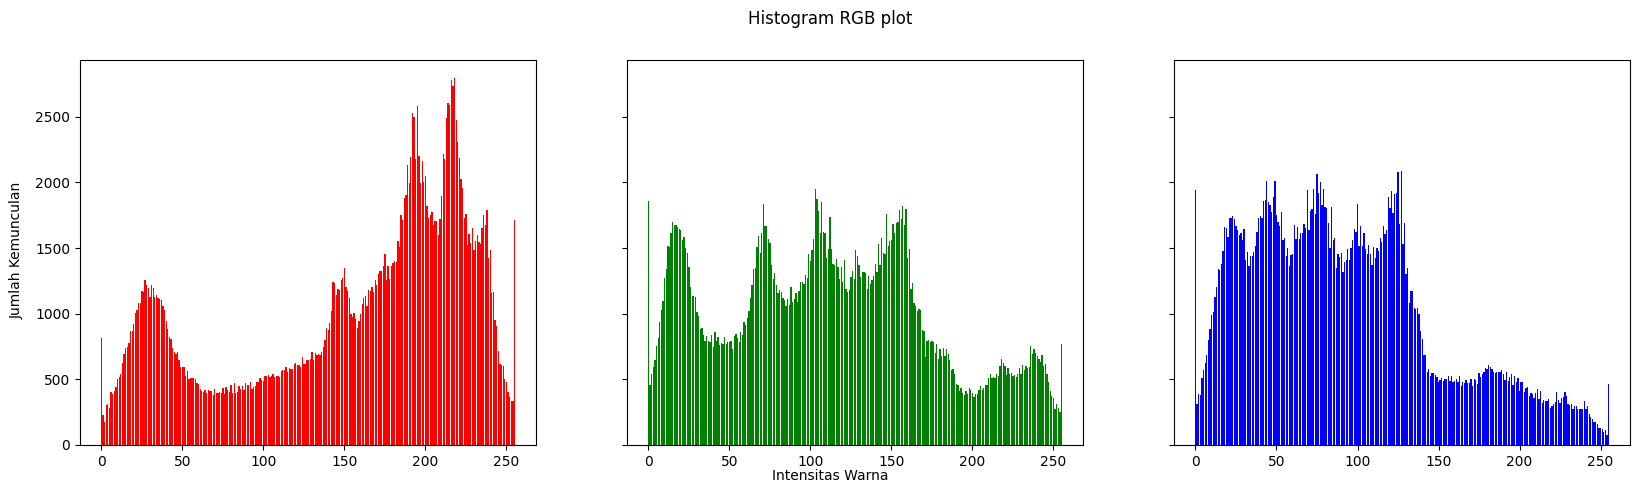

In [ ]:
# 1. Membuat histogram image (manual)
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 2. Baca gambar
img = cv.imread('/content/drive/MyDrive/Image/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# 3. Ambil ukuran gambar
height, width, depth = np.shape(img)
names = np.arange(256)

# 4. Inisialisasi array untuk histogram RGB
red = [0] * 256
green = [0] * 256
blue = [0] * 256

# 5. Hitung frekuensi intensitas tiap warna
for y in range(0, height):
    for x in range(0, width):
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

# 6. Plot histogram RGB
names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')

axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

plt.show()


## PERTANYAAN PRAKTIKUM D1
1. Buatlah histogram citra yang sama akan tetapi menggunakan library yang dimiliki oleh
NumPy yaitu “histogram”. Bandingkan hasilnya. Apakah output muncul sama?
2. Buatlah histogram dengan menggunakan dengan menggunakan image KTM lama.jpg.
Analisis distribusi intensitas dari histogram yang dihasilkan apakah gambar cenderung
gelap, terang, atau kontras rendah.

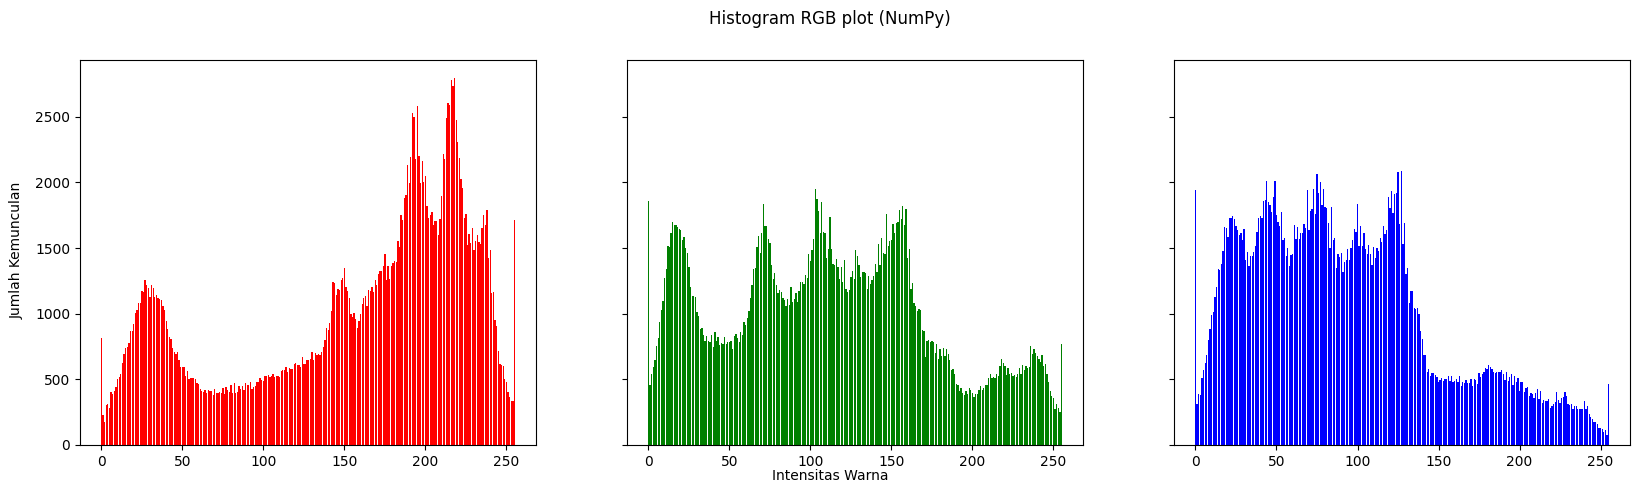

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Baca gambar
img = cv.imread('/content/drive/MyDrive/Image/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Pisahkan channel R, G, B
red_channel = img[:, :, 0].ravel()
green_channel = img[:, :, 1].ravel()
blue_channel = img[:, :, 2].ravel()

# Hitung histogram dengan numpy
red_hist, bins = np.histogram(red_channel, bins=256, range=(0, 256))
green_hist, bins = np.histogram(green_channel, bins=256, range=(0, 256))
blue_hist, bins = np.histogram(blue_channel, bins=256, range=(0, 256))

# Plot histogram
names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot (NumPy)')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')

axs[0].bar(names, red_hist, color='red')
axs[1].bar(names, green_hist, color='green')
axs[2].bar(names, blue_hist, color='blue')

plt.show()


1. Perbandingan hasil:

Versi manual: kita menghitung jumlah piksel tiap intensitas dengan for loop.

Versi NumPy: np.histogram langsung menghitung distribusi intensitas tiap channel.
Outputnya akan sama, karena keduanya menghitung hal yang identik (jumlah kemunculan tiap nilai intensitas 0–255).

Bedanya hanya di efisiensi: np.histogram jauh lebih cepat karena ditulis dalam C dan teroptimasi, sedangkan for loop manual lambat.

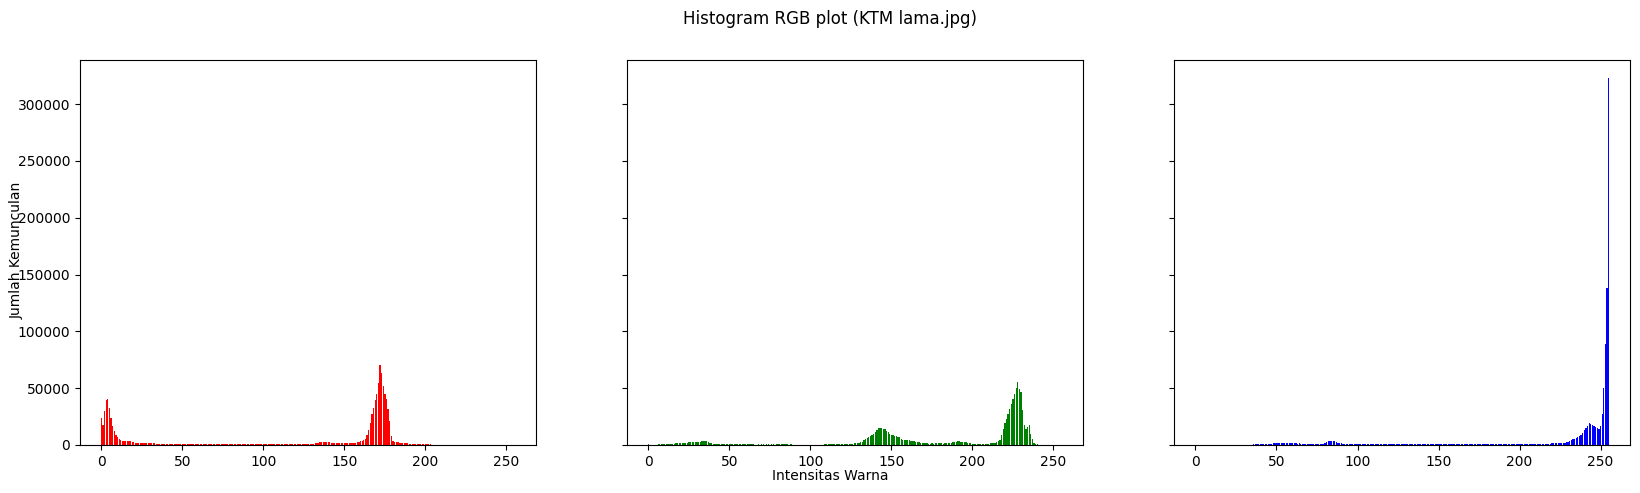

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Baca gambar (ganti path sesuai lokasi file kamu)
img = cv.imread('/content/drive/MyDrive/Image/KTM.jpeg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Pisahkan channel R, G, B
red_channel = img[:, :, 0].ravel()
green_channel = img[:, :, 1].ravel()
blue_channel = img[:, :, 2].ravel()

# Hitung histogram dengan NumPy
red_hist, _ = np.histogram(red_channel, bins=256, range=(0, 256))
green_hist, _ = np.histogram(green_channel, bins=256, range=(0, 256))
blue_hist, _ = np.histogram(blue_channel, bins=256, range=(0, 256))

# Plot histogram
names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot (KTM lama.jpg)')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')

axs[0].bar(names, red_hist, color='red')
axs[1].bar(names, green_hist, color='green')
axs[2].bar(names, blue_hist, color='blue')

plt.show()


2. Hasil

Channel merah (R) terlihat ada distribusi di intensitas rendah (sekitar 0–20) dan juga puncak di intensitas menengah (sekitar 170–180). Ini berarti ada bagian gelap (hitam/merah gelap) sekaligus area yang agak terang.

Channel hijau (G) distribusi paling banyak ada di rentang 200–240, artinya banyak piksel cenderung terang pada kanal hijau.

Channel biru (B) puncaknya sangat tinggi di ujung kanan (sekitar 250), menunjukkan dominasi warna biru sangat terang/putih di gambar.

Kesimpulan distribusi intensitas:
Histogram cenderung menumpuk di sisi kanan (200–255), terutama pada kanal hijau dan biru. <br>
Ini menunjukkan gambar cenderung terang (bright image). <br>
Namun karena ada beberapa puncak di kiri (gelap) tapi jumlahnya sedikit, gambar masih memiliki sedikit area gelap.
Kontrasnya tidak terlalu rendah, karena histogram tidak hanya menumpuk di tengah, melainkan tersebar ke kiri dan kanan jadi masih ada perbedaan gelap terang yang jelas.

# Praktikum 2 Langkah 1

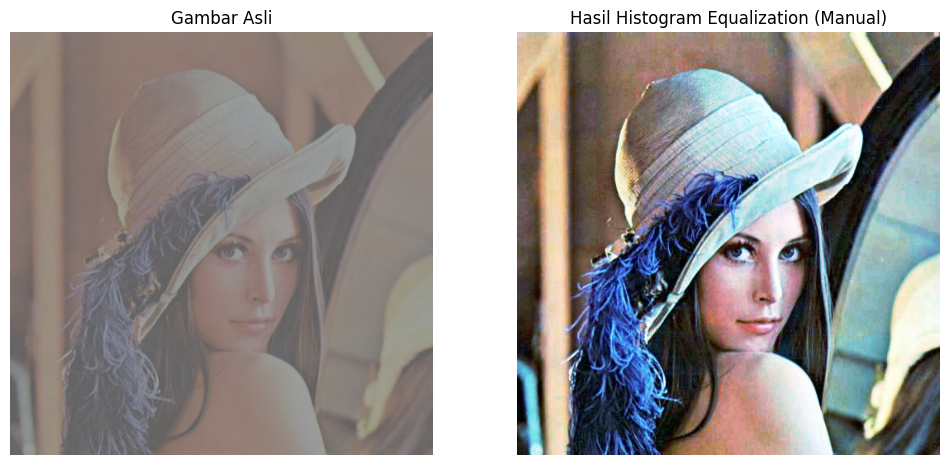

/tmp/ipython-input-2585657222.py:52: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[0,0].hist(r.flatten(), 256, [0,256], color='r')
/tmp/ipython-input-2585657222.py:55: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[0,1].hist(g.flatten(), 256, [0,256], color='g')
/tmp/ipython-input-2585657222.py:58: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[0,2].hist(b.flatten(), 256, [0,256], color='b')
/tmp/ipython-input-2585657222.py:62: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[1,0].hist(r_eq.flatt

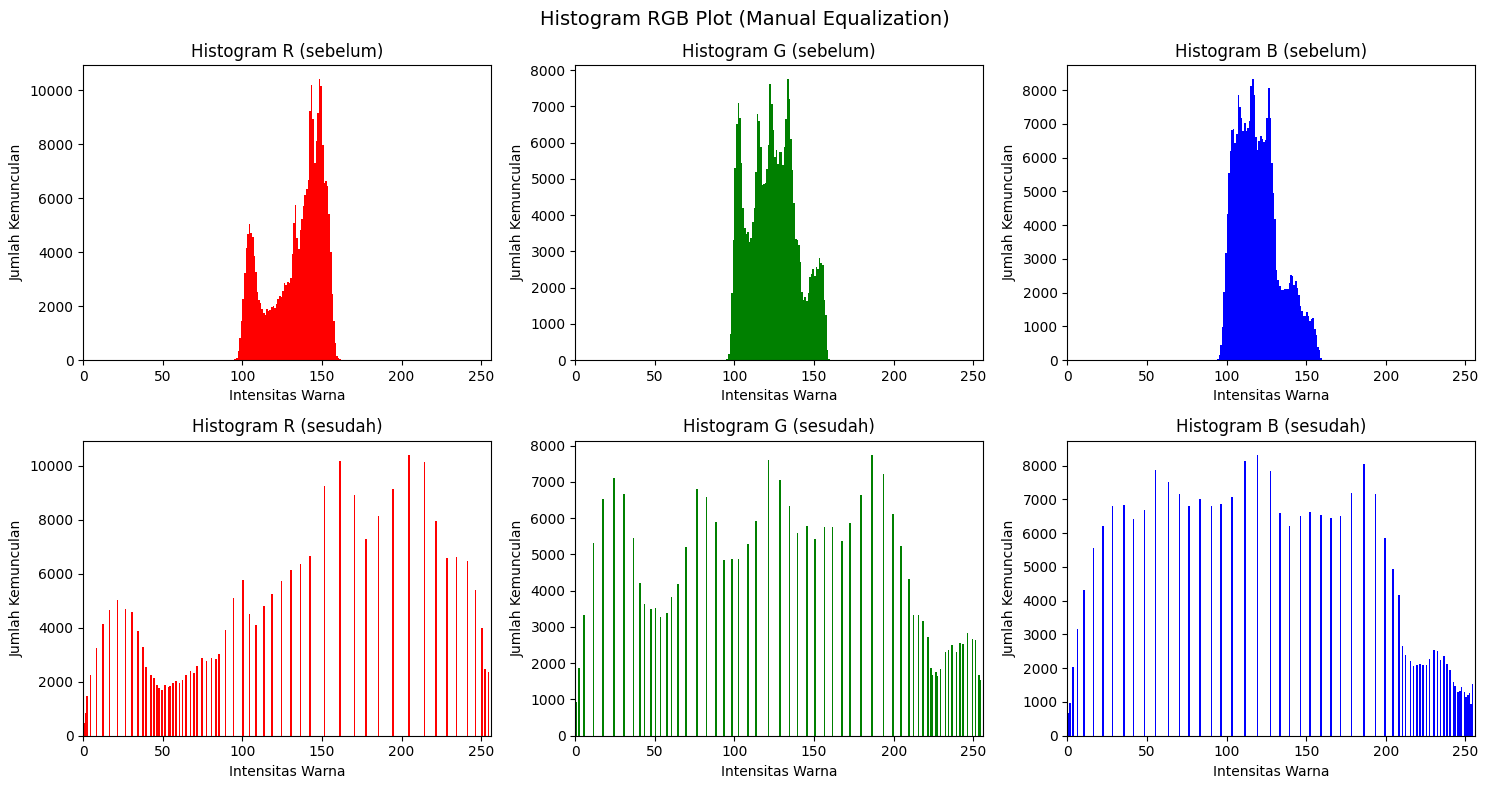

In [ ]:


import cv2
import numpy as np
import matplotlib.pyplot as plt


image = cv2.imread('/content/drive/MyDrive/Image/lena_lc.jpg')
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Pisahkan channel
r, g, b = cv2.split(image_rgb)


def manual_equalize(channel):

    hist, bins = np.histogram(channel.flatten(), 256, [0,256])

    cdf = hist.cumsum()

    cdf_normalized = (cdf - cdf.min()) * 255 / (cdf.max() - cdf.min())
    cdf_final = cdf_normalized.astype('uint8')

    img_eq = cdf_final[channel]
    return img_eq


r_eq = manual_equalize(r)
g_eq = manual_equalize(g)
b_eq = manual_equalize(b)


img_eq_manual = cv2.merge((r_eq, g_eq, b_eq))


plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(image_rgb)
plt.title("Gambar Asli")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_eq_manual)
plt.title("Hasil Histogram Equalization (Manual)")
plt.axis("off")

plt.show()


fig, axes = plt.subplots(2, 3, figsize=(15,8))


axes[0,0].hist(r.flatten(), 256, [0,256], color='r')
axes[0,0].set_title("Histogram R (sebelum)")

axes[0,1].hist(g.flatten(), 256, [0,256], color='g')
axes[0,1].set_title("Histogram G (sebelum)")

axes[0,2].hist(b.flatten(), 256, [0,256], color='b')
axes[0,2].set_title("Histogram B (sebelum)")


axes[1,0].hist(r_eq.flatten(), 256, [0,256], color='r')
axes[1,0].set_title("Histogram R (sesudah)")

axes[1,1].hist(g_eq.flatten(), 256, [0,256], color='g')
axes[1,1].set_title("Histogram G (sesudah)")

axes[1,2].hist(b_eq.flatten(), 256, [0,256], color='b')
axes[1,2].set_title("Histogram B (sesudah)")

for ax in axes.flat:
    ax.set_xlim([0,256])
    ax.set_xlabel("Intensitas Warna")
    ax.set_ylabel("Jumlah Kemunculan")

plt.suptitle("Histogram RGB Plot (Manual Equalization)", fontsize=14)
plt.tight_layout()
plt.show()


## Langkah 2

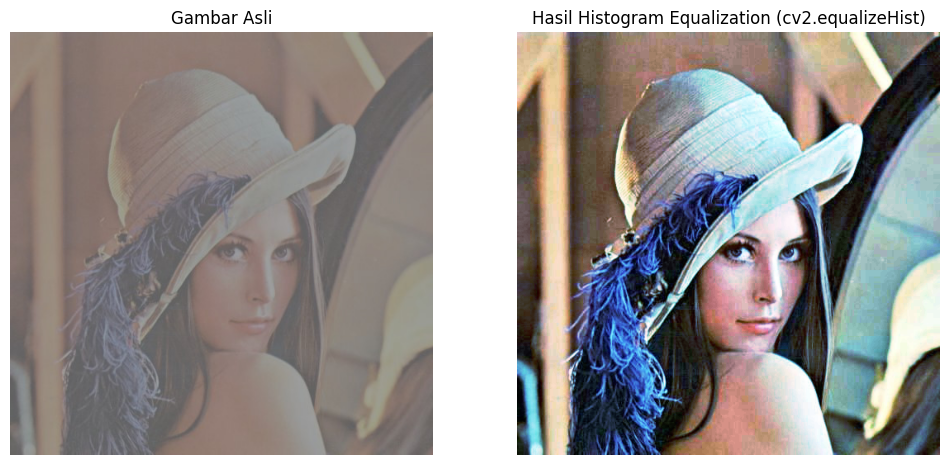

/tmp/ipython-input-1192209130.py:39: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[0,0].hist(r.flatten(), 256, [0,256], color='r')
/tmp/ipython-input-1192209130.py:42: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[0,1].hist(g.flatten(), 256, [0,256], color='g')
/tmp/ipython-input-1192209130.py:45: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[0,2].hist(b.flatten(), 256, [0,256], color='b')
/tmp/ipython-input-1192209130.py:49: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[1,0].hist(r_eq.flatt

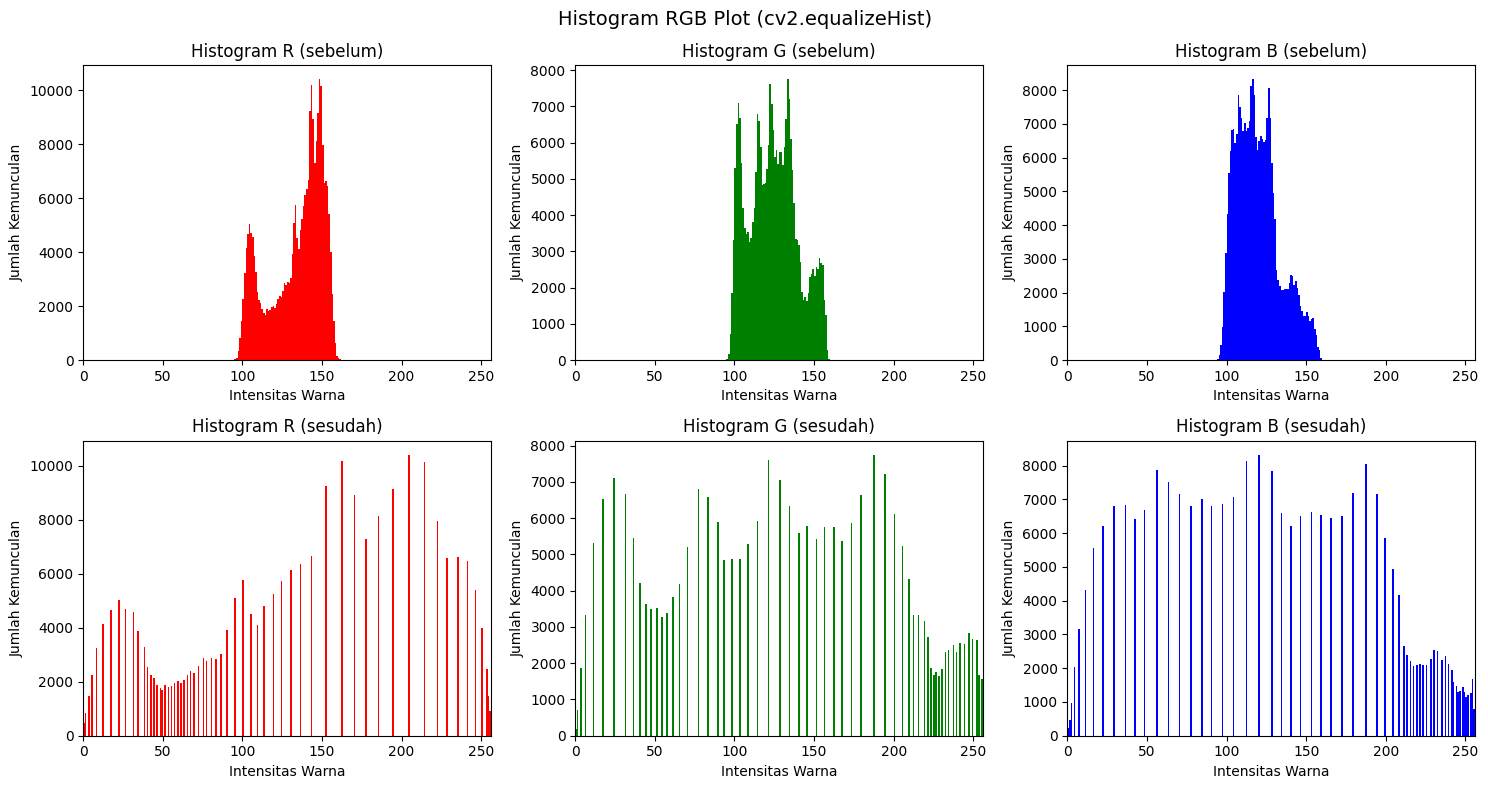

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Baca gambar
image = cv2.imread('/content/drive/MyDrive/Image/lena_lc.jpg')
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Pisahkan channel BGR
b, g, r = cv2.split(image)

# Equalization dengan fungsi bawaan OpenCV
b_eq = cv2.equalizeHist(b)
g_eq = cv2.equalizeHist(g)
r_eq = cv2.equalizeHist(r)

# Gabungkan kembali (BGR lalu convert ke RGB biar bisa ditampilkan dengan matplotlib)
img_eq_cv2 = cv2.merge((b_eq, g_eq, r_eq))
img_eq_cv2_rgb = cv2.cvtColor(img_eq_cv2, cv2.COLOR_BGR2RGB)

# Tampilkan gambar asli dan hasil equalization
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(image_rgb)
plt.title("Gambar Asli")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_eq_cv2_rgb)
plt.title("Hasil Histogram Equalization (cv2.equalizeHist)")
plt.axis("off")

plt.show()

# Plot histogram sebelum dan sesudah
fig, axes = plt.subplots(2, 3, figsize=(15,8))

axes[0,0].hist(r.flatten(), 256, [0,256], color='r')
axes[0,0].set_title("Histogram R (sebelum)")

axes[0,1].hist(g.flatten(), 256, [0,256], color='g')
axes[0,1].set_title("Histogram G (sebelum)")

axes[0,2].hist(b.flatten(), 256, [0,256], color='b')
axes[0,2].set_title("Histogram B (sebelum)")


axes[1,0].hist(r_eq.flatten(), 256, [0,256], color='r')
axes[1,0].set_title("Histogram R (sesudah)")

axes[1,1].hist(g_eq.flatten(), 256, [0,256], color='g')
axes[1,1].set_title("Histogram G (sesudah)")

axes[1,2].hist(b_eq.flatten(), 256, [0,256], color='b')
axes[1,2].set_title("Histogram B (sesudah)")

for ax in axes.flat:
    ax.set_xlim([0,256])
    ax.set_xlabel("Intensitas Warna")
    ax.set_ylabel("Jumlah Kemunculan")

plt.suptitle("Histogram RGB Plot (cv2.equalizeHist)", fontsize=14)
plt.tight_layout()
plt.show()


1. Perbandingan Citra Lena <br>
a. Gunakan hasil histogram equalization pada citra lena.jpg. <br>
b. Hitung nilai PSNR antara citra asli dan citra hasil equalization. <br>
c. Apakah nilai PSNR tinggi atau rendah? Apa arti nilai tersebut terhadap kualitas
visual citra? Apakah ada detail baru yang muncul setelah equalization?

PSNR (original vs equalize cv2 per-channel)  : 12.6624 dB
PSNR (original vs equalize manual per-channel): 12.6612 dB


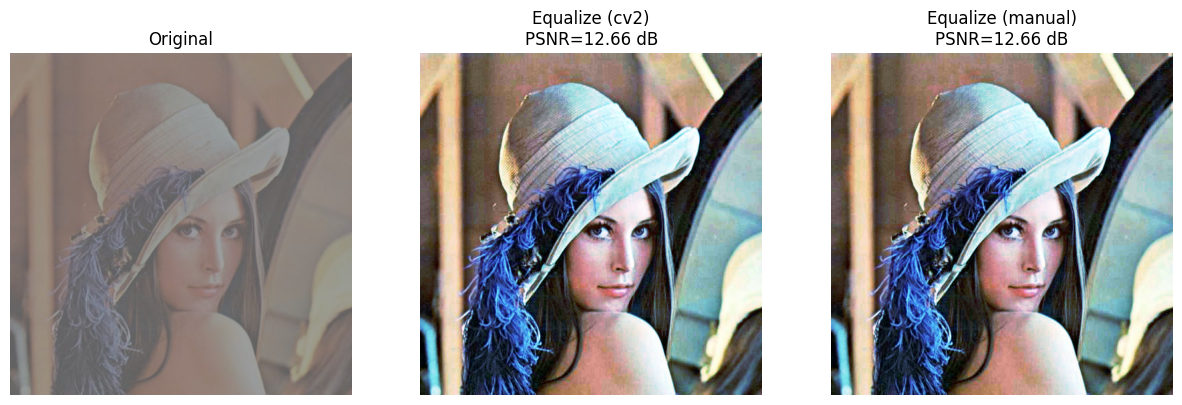

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


path = '/content/drive/MyDrive/Image/lena_lc.jpg'
img_bgr = cv2.imread(path)
if img_bgr is None:
    raise FileNotFoundError(f"Gambar tidak ditemukan: {path}")
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


b, g, r = cv2.split(img_bgr)
b_eq = cv2.equalizeHist(b)
g_eq = cv2.equalizeHist(g)
r_eq = cv2.equalizeHist(r)
img_eq_bgr = cv2.merge((b_eq, g_eq, r_eq))
img_eq_rgb = cv2.cvtColor(img_eq_bgr, cv2.COLOR_BGR2RGB)


def manual_equalize(channel):
    hist, _ = np.histogram(channel.flatten(), 256, [0,256])
    cdf = hist.cumsum()
    cdf_normalized = (cdf - cdf.min()) * 255.0 / (cdf.max() - cdf.min())
    cdf_final = cdf_normalized.astype('uint8')
    return cdf_final[channel]


b_man = manual_equalize(b)
g_man = manual_equalize(g)
r_man = manual_equalize(r)
img_eq_manual_bgr = cv2.merge((b_man, g_man, r_man))
img_eq_manual_rgb = cv2.cvtColor(img_eq_manual_bgr, cv2.COLOR_BGR2RGB)


def psnr(img1, img2):
    # pastikan tipe float64 untuk perhitungan
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf')
    PIXEL_MAX = 255.0
    return 10 * np.log10((PIXEL_MAX ** 2) / mse)

# Hitung PSNR: antara original (RGB) dan hasil equalize (RGB)
psnr_cv2 = psnr(img_rgb, img_eq_rgb)
psnr_manual = psnr(img_rgb, img_eq_manual_rgb)

print(f"PSNR (original vs equalize cv2 per-channel)  : {psnr_cv2:.4f} dB")
print(f"PSNR (original vs equalize manual per-channel): {psnr_manual:.4f} dB")

# ---- tampilkan gambar dan histogram (ringkas) ----
fig, axs = plt.subplots(1,3, figsize=(15,5))
axs[0].imshow(img_rgb); axs[0].set_title('Original'); axs[0].axis('off')
axs[1].imshow(img_eq_rgb); axs[1].set_title(f'Equalize (cv2)\nPSNR={psnr_cv2:.2f} dB'); axs[1].axis('off')
axs[2].imshow(img_eq_manual_rgb); axs[2].set_title(f'Equalize (manual)\nPSNR={psnr_manual:.2f} dB'); axs[2].axis('off')
plt.show()


C. Nilai **PSNR** yang diperoleh setelah histogram equalization biasanya relatif lebih rendah dibandingkan citra asli karena terjadi perubahan intensitas pada hampir semua piksel, tetapi hal ini tidak berarti kualitas visual citra menurun; sebaliknya, equalization justru meningkatkan kontras sehingga detail yang sebelumnya kurang terlihat pada area gelap atau terang menjadi lebih jelas. Dengan kata lain, PSNR rendah hanya menunjukkan adanya perbedaan numerik besar antara citra asli dan hasil equalization, sedangkan secara persepsi visual citra bisa tampak lebih informatif karena detail tersembunyi muncul lebih nyata, meskipun terkadang noise juga ikut lebih terlihat.


D-3 TUGAS PRAKTIKUM DITHERING

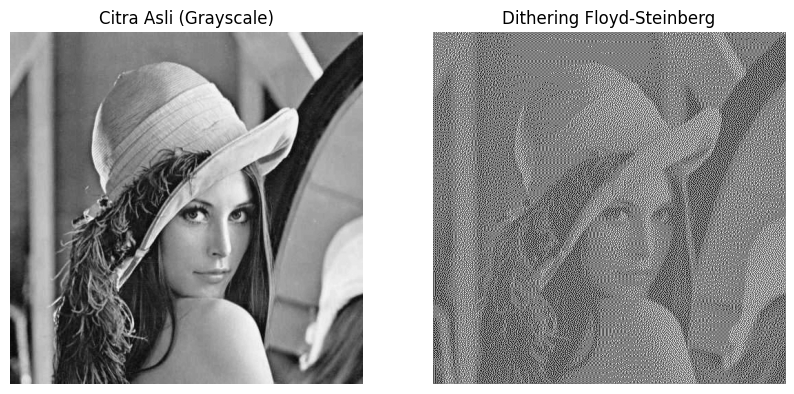

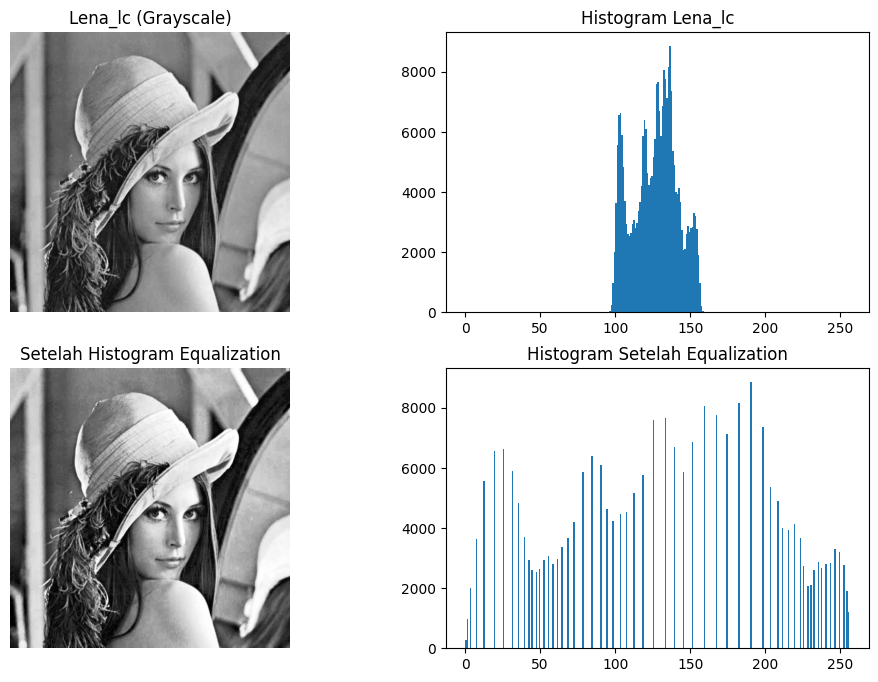

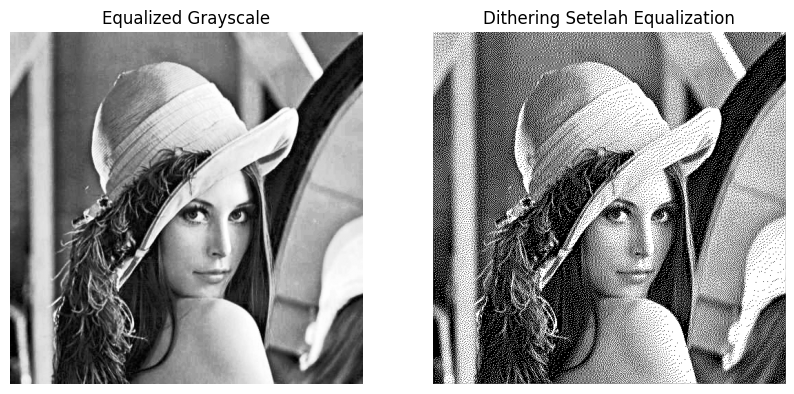

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def floyd_steinberg_dithering(image):
    # Pastikan citra dalam grayscale (0-255)
    img = image.astype(float)
    h, w = img.shape

    for y in range(h - 1):
        for x in range(1, w - 1):
            old_pixel = img[y, x]
            new_pixel = 0 if old_pixel < 128 else 255
            img[y, x] = new_pixel
            error = old_pixel - new_pixel

            # Sebarkan error sesuai Floyd-Steinberg
            img[y, x+1]   += error * 7/16
            img[y+1, x-1] += error * 3/16
            img[y+1, x]   += error * 5/16
            img[y+1, x+1] += error * 1/16

    return np.clip(img, 0, 255).astype(np.uint8)


path_lena = '/content/drive/MyDrive/Image/lena_lc.jpg'
lena = cv2.imread(path_lena, cv2.IMREAD_GRAYSCALE)

dither_lena = floyd_steinberg_dithering(lena)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(lena, cmap="gray")
plt.title("Citra Asli (Grayscale)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(dither_lena, cmap="gray")
plt.title("Dithering Floyd-Steinberg")
plt.axis("off")
plt.show()


path_lena_lc = '/content/drive/MyDrive/Image/lena_lc.jpg'
lena_lc = cv2.imread(path_lena_lc, cv2.IMREAD_GRAYSCALE)

# Histogram Equalization
equalized = cv2.equalizeHist(lena_lc)

# Dithering setelah histogram equalization
dither_equalized = floyd_steinberg_dithering(equalized)

# Plot hasil
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(lena_lc, cmap="gray")
plt.title("Lena_lc (Grayscale)")
plt.axis("off")

plt.subplot(2,2,2)
plt.hist(lena_lc.ravel(), bins=256, range=(0,256))
plt.title("Histogram Lena_lc")

plt.subplot(2,2,3)
plt.imshow(equalized, cmap="gray")
plt.title("Setelah Histogram Equalization")
plt.axis("off")

plt.subplot(2,2,4)
plt.hist(equalized.ravel(), bins=256, range=(0,256))
plt.title("Histogram Setelah Equalization")

plt.show()

# Tampilkan hasil dithering setelah equalization
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(equalized, cmap="gray")
plt.title("Equalized Grayscale")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(dither_equalized, cmap="gray")
plt.title("Dithering Setelah Equalization")
plt.axis("off")
plt.show()
